# Two-Layer Teacher Temperature LR Sweep

We define an energy function $T: \mathbb{R}^{d} \to \mathbb{R}^{k}$, where $T$ takes the form
$$
T(x) = \frac{1}{\gamma n^{a_{2}}}W^{2} g\left( \frac{1}{d^{a_{1}}}W^{1} x \right),
$$
with (1) $W^2 =^{d} G\sqrt{ \Sigma }$ for $G \sim \mathcal{N}(0, n^{-b_{2}} I_{k \times n})$ and $\Sigma \in \mathbb{R}^{n \times n}$ diagonal and deterministic with $\Sigma_{ii} = i^{-2\alpha}$ for some $\alpha > 0$; (2) $W^{1} \sim \mathcal{N}(0, d^{-b_{1}}I_{n \times d})$; and (3) $g \in C^{1}(\mathbb{R})$ acting elementwise. We refer to this as a random sample from the ensemble $(d, n, k, \Sigma)$.

Define $h^{1} =  \frac{1}{\sqrt{ d }}W^{1} x$ and $h^{2} = \gamma T(x)$.

We choose the exponents in the teacher in order to (1) keep the RMS norms of $h^{1}$ and $h^{2}$ order-1 at initialization and to (2) also keep the feature map $\frac{\partial T}{\partial h^{1}}$ with RMS norm $\Theta(1)$. Indeed, for $\alpha \neq \frac{1}{2}$ the space of allowable scalings is
$$
b_{1}​=1−2a_{1}​,b_{2}​=s_{\alpha}​−2a_{2}​−2c,
$$
where $\gamma = n^{c}$ for $c \geq 0$ and 

$$
s_{\alpha} = \log_{n}\sum_{i = 1}^{n} n^{-2\alpha} \sim 
\begin{cases}
1 - 2 \alpha & \alpha < \frac{1}{2} \\
0 & \alpha > \frac{1}{2}.
\end{cases}
$$
We provisionally consider the easy regime $\alpha > \frac{1}{2}$, and make a choice of scalings that doesn't fully absorb the power exponent of $\gamma$ into $a_{2}$:
$$
\gamma=n^{c},a_{1}​=\frac{1}{2}​,b_{1}​=0,a_{2}​=\frac{s_{\alpha}−2c}{4}​ = -\frac{c}{2},b_{2}​=\frac{s_{\alpha}​−2c}{2}​ = -c.​
$$

We consider the following experimental procedure:

1. Randomly draw a teacher from the ensemble $(d, n, k, \Sigma)$ and a student from the ensemble $(d, \kappa n, k, I_{n})$.
2. Draw $p$ samples $x_{1},\dots ,x_{p} \sim^{\text{iid}} \mathcal{N}(0, I_{d})$. Randomly sample labels $y_{1}, \dots, y_{p}$ from the $\beta$-inverse temperature Gibbs distribution 
$$
P(y_{i} = j |x_{i}) \propto \exp(\beta T_{j}(x_{i})).
$$ 
We will consider the full set of $p$ samples to be the population.
We use the Gumbel-max trick as necessary to simulate sampling.
3. Train the student network using $T$ steps of `IterativeOptimizationProcedure` using the one-hot cross-entropy loss.

We will sweep this experimental procedure over $\beta$ in log space, from $\beta = 10^{-3}$ to $10^{2}$. 

First, let's find the optimal learning rate for each $\beta$ when using the SGD optimizer. Choose $d = k = 100$, $n = 3d = 300$, $\alpha = \frac{3}{4}$, $p = 4n = 1200$.

We want to plot a Pareto curve for each $\beta$: learning rate on the x-axis, population loss after 100 steps on the y-axis. We make two of these plots: one with minibatch size 32, one with population gradient descent.

In [7]:
import sys
from pathlib import Path

# Add parent directory to path to import two_layer_experiment
sys.path.insert(0, str(Path('.').resolve().parent))

from pathlib import Path
import matplotlib.pyplot as plt

from two_layer_experiment.results import best_learning_rates, load_results
from two_layer_experiment.plotting import pareto_plot

runs_dir = Path('../runs/two_layer_lr_sweep')
df = load_results(runs_dir)
best = best_learning_rates(df)
best

,mode,beta,lr,step,population_xent,population_logit_mse
0,minibatch32,0.001000,87.992254,1000,0.004888,572.402832
1,minibatch32,0.006813,87.992254,1000,0.000503,574.498962
2,minibatch32,0.046416,87.992254,1000,0.000035,555.575439
3,minibatch32,0.316228,87.992254,1000,0.000046,547.581604
4,minibatch32,2.154435,87.992254,1000,0.000031,625.582520
5,minibatch32,14.677993,87.992254,1000,0.000009,635.990540
6,minibatch32,100.000000,87.992254,1000,0.000012,618.436829
7,population,0.001000,316.227766,1000,0.000762,27.160259
8,population,0.006813,316.227766,1000,0.000762,27.130306
9,population,0.046416,316.227766,1000,0.000763,27.048380


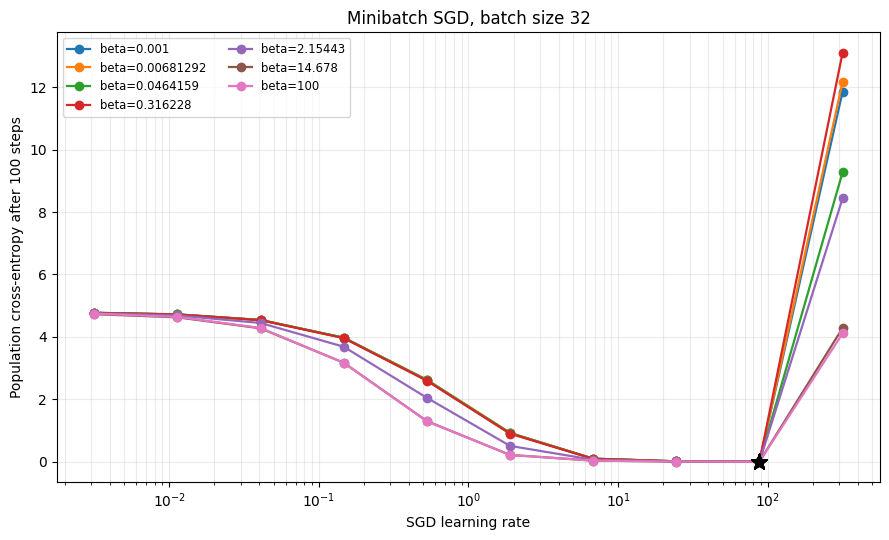

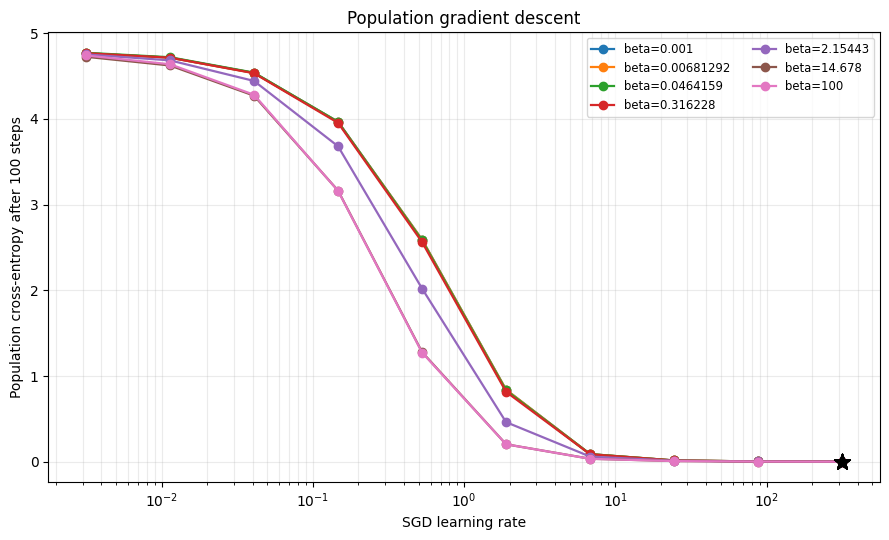

In [8]:
for mode in ['minibatch32', 'population']:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    pareto_plot(df, mode, ax=ax)
    fig.tight_layout()
    fig.savefig(runs_dir / f'pareto_{mode}.png', dpi=180)
    plt.show()

In [9]:
def best_lr_timeseries(df, best, mode):
    rows = []
    for _, row in best[best['mode'] == mode].iterrows():
        rows.append(df[(df['mode'] == mode) & (df['beta'] == row['beta']) & (df['lr'] == row['lr'])])
    return __import__('pandas').concat(rows, ignore_index=True)

def plot_metric_over_time(ts, metric, mode):
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for beta, group in ts.groupby('beta', sort=True):
        group = group.sort_values('step')
        ax.plot(group['step'], group[metric], marker='o', linewidth=1.5, label=f'beta={beta:g}')
    ax.set_title(f'{mode}: {metric} at best final-xent LR')
    ax.set_xlabel('SGD step')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.25)
    ax.legend(ncols=2, fontsize='small')
    fig.tight_layout()
    fig.savefig(runs_dir / f'time_{mode}_{metric}.png', dpi=180)
    return fig

time_metrics = [
    'teacher_h1_rms',
    'teacher_h2_rms',
    'student_h1_rms',
    'student_h2_rms',
    'student_df_dh1_rms',
    'population_xent',
    'population_logit_mse',
    'w1_cosine_fro',
]

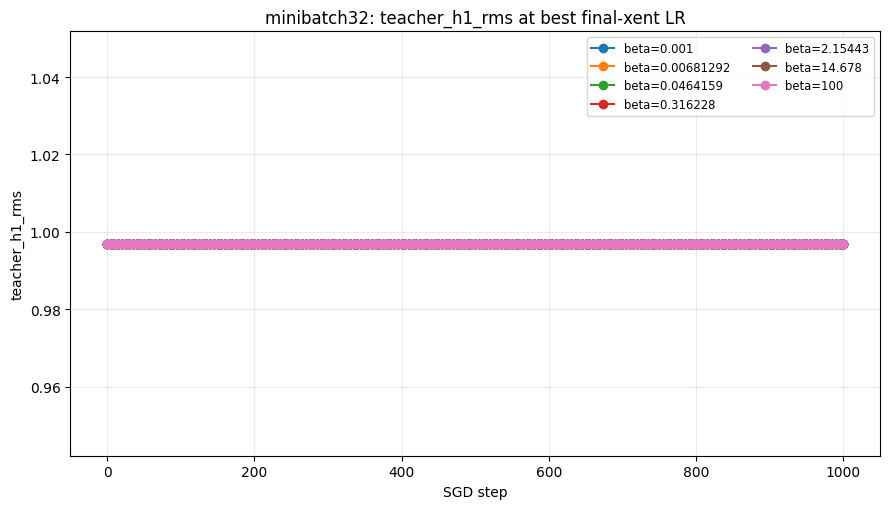

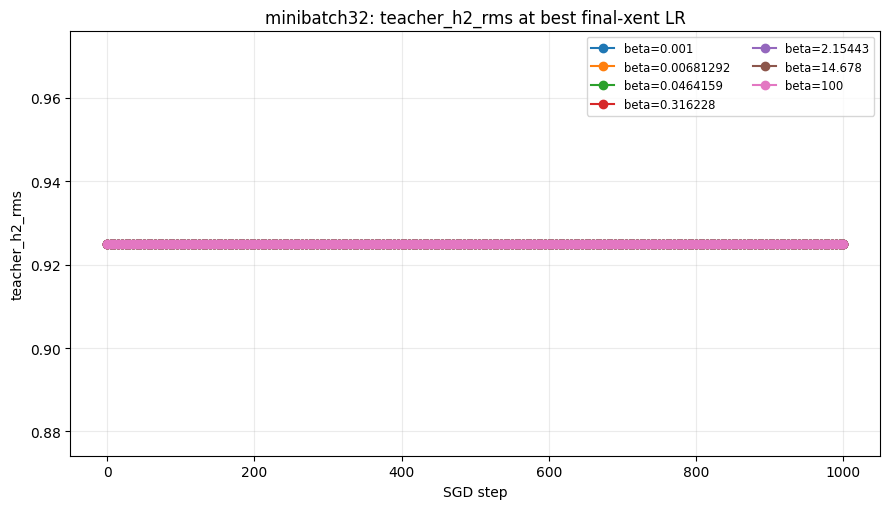

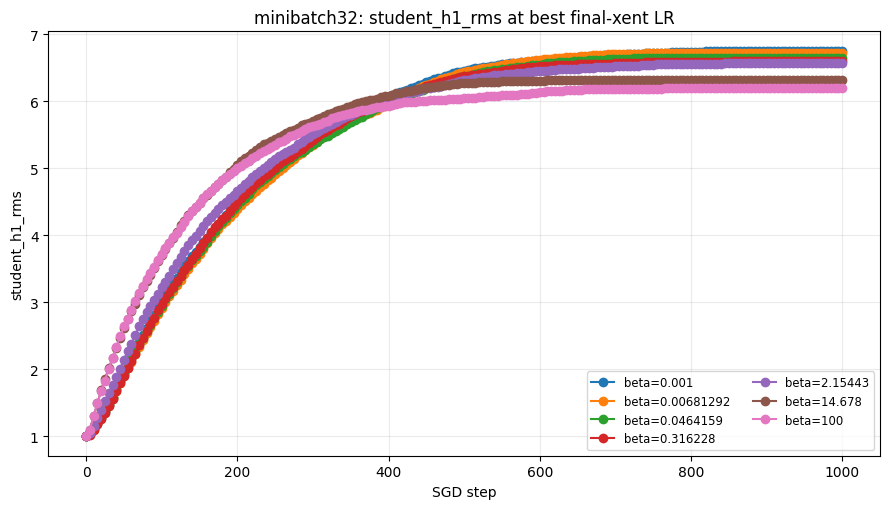

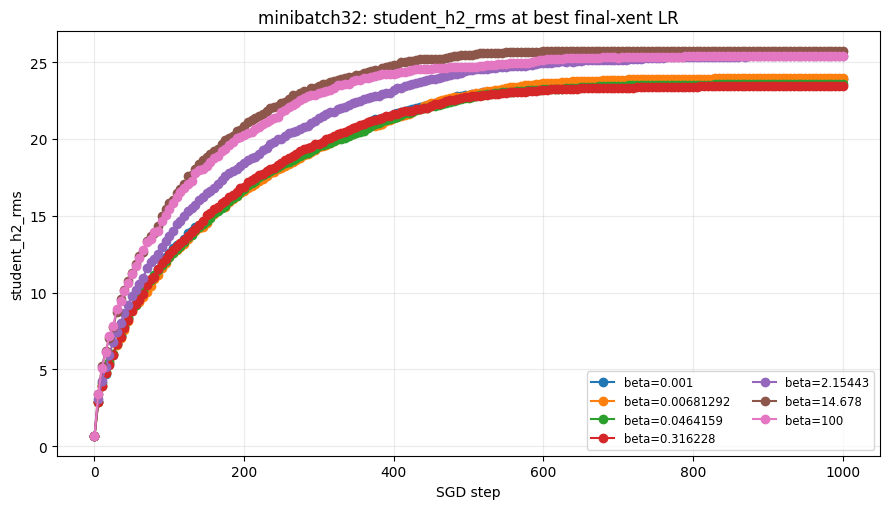

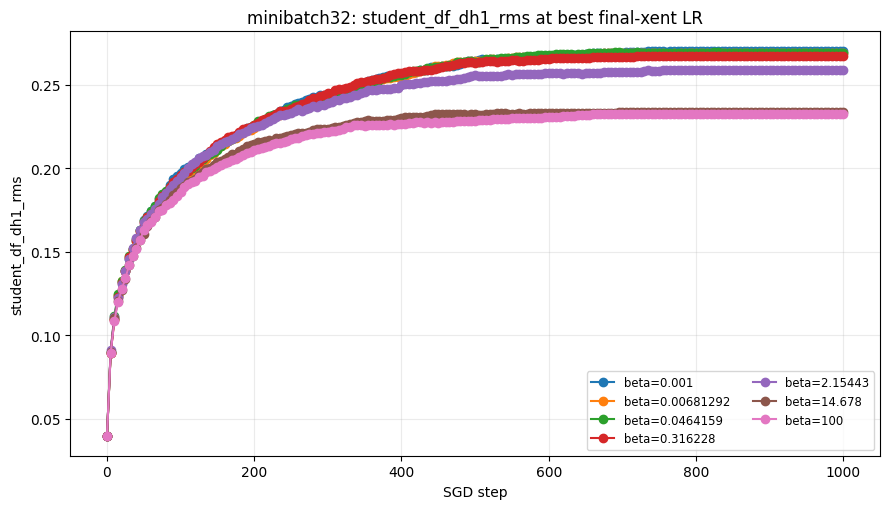

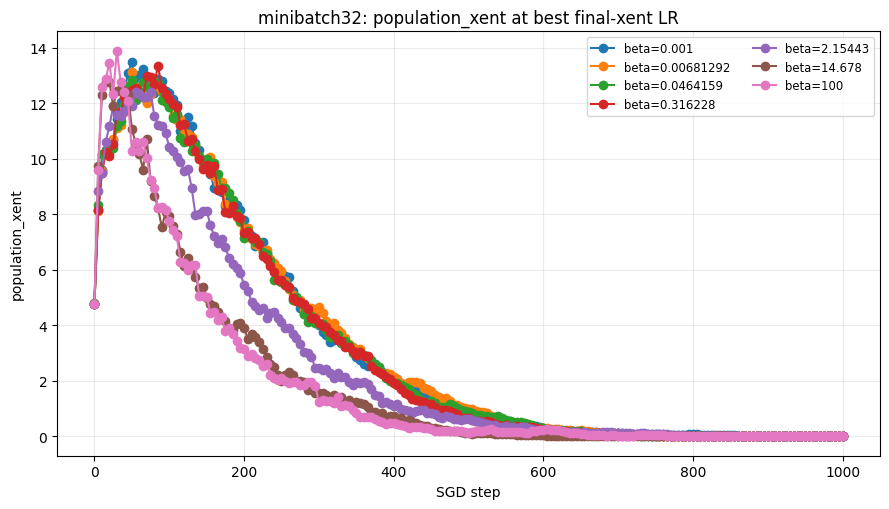

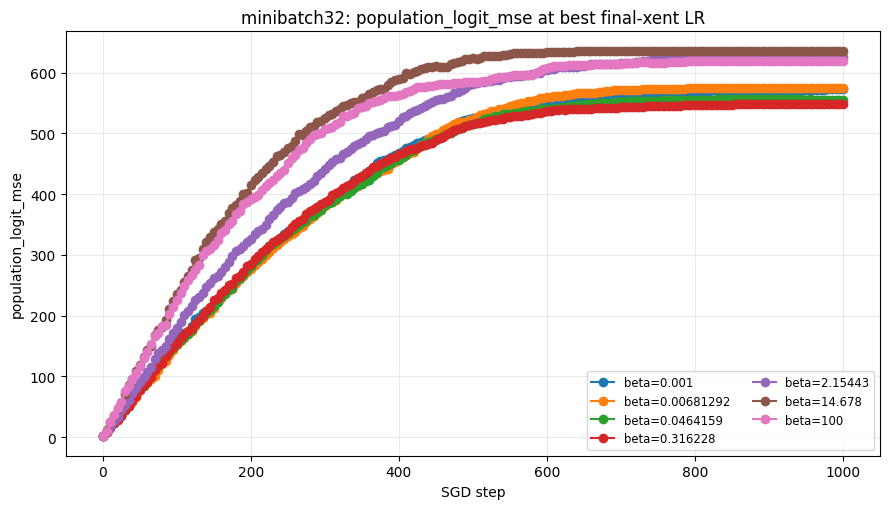

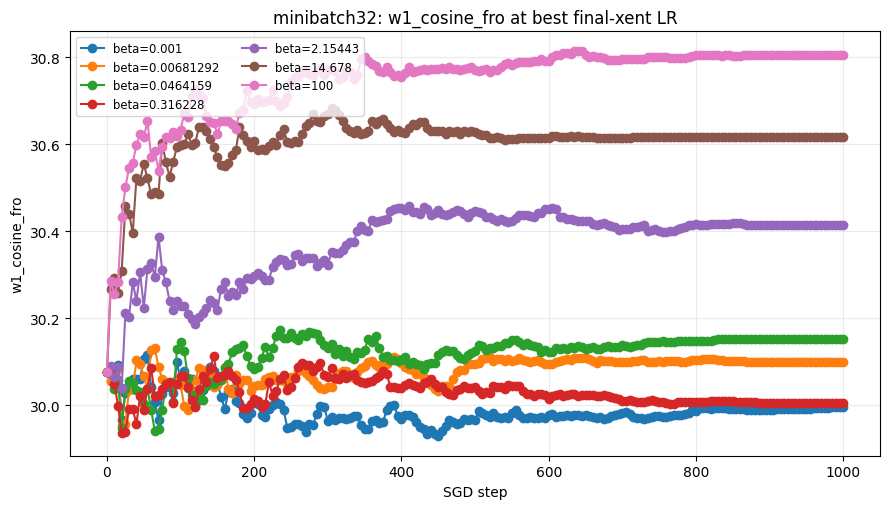

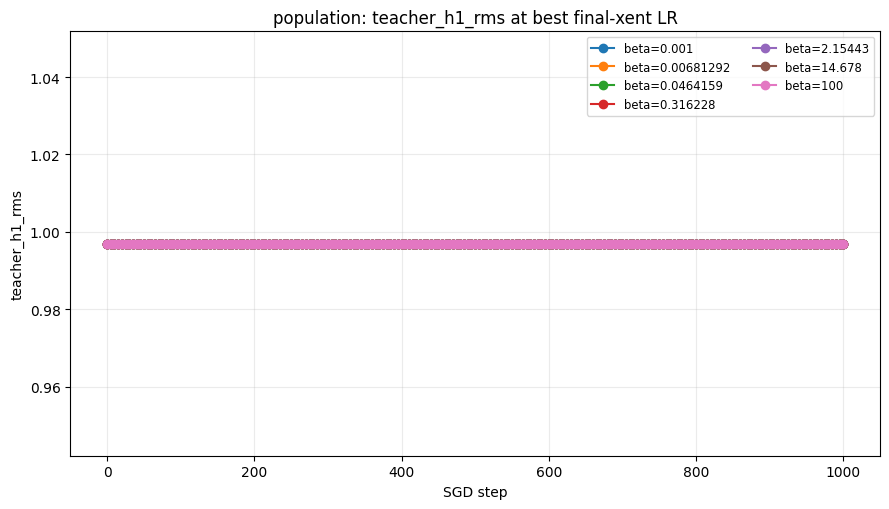

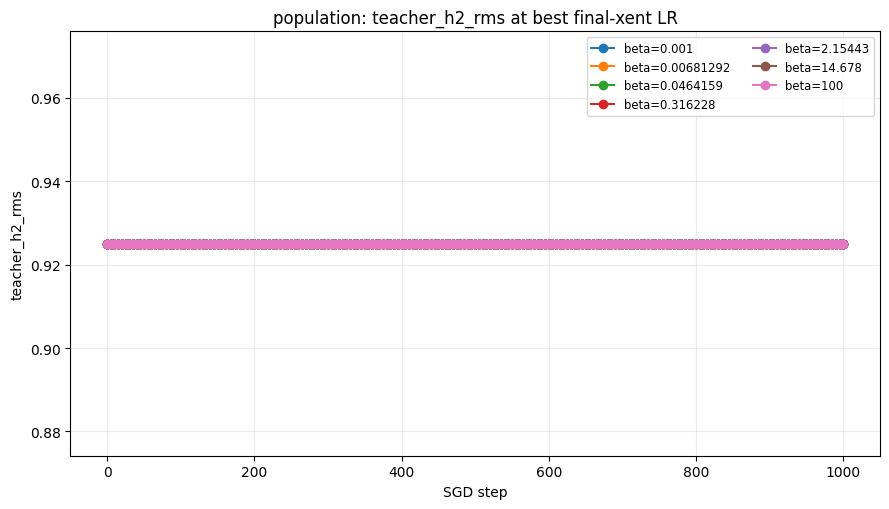

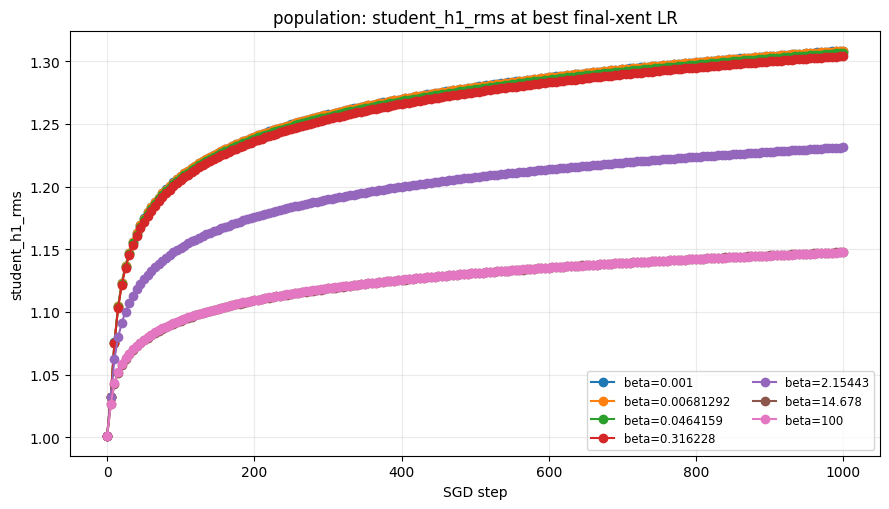

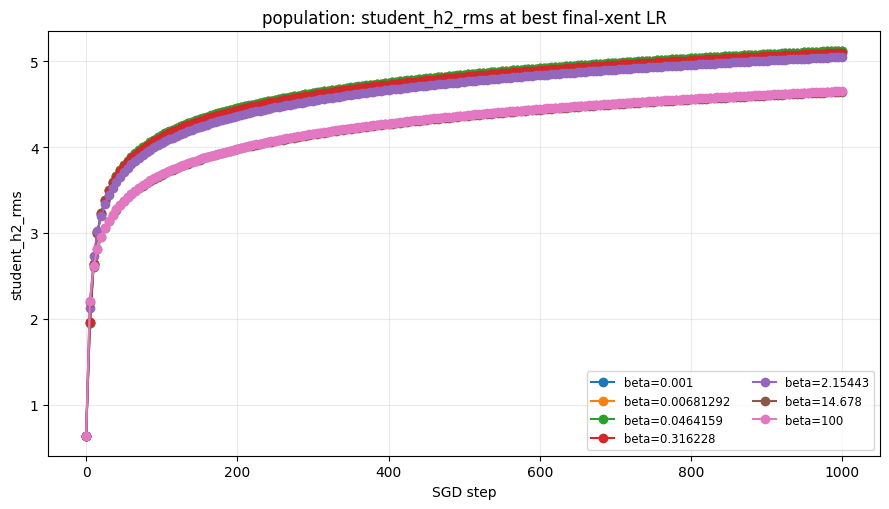

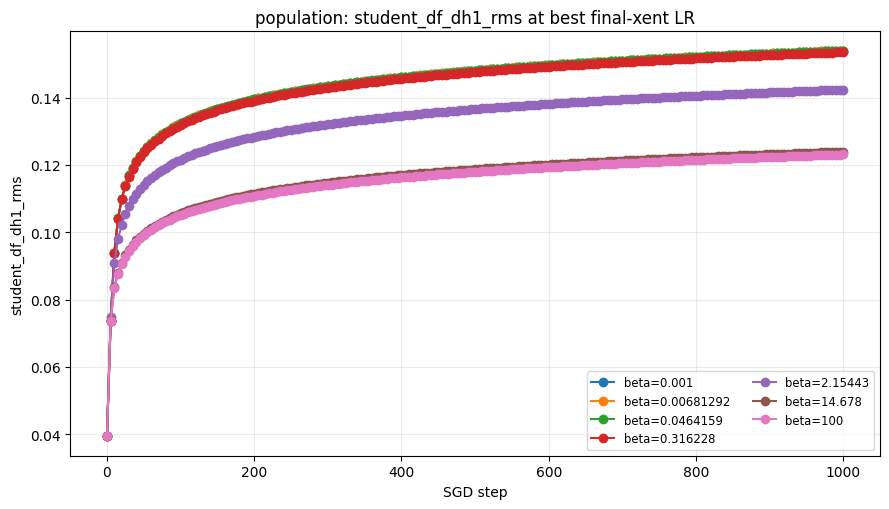

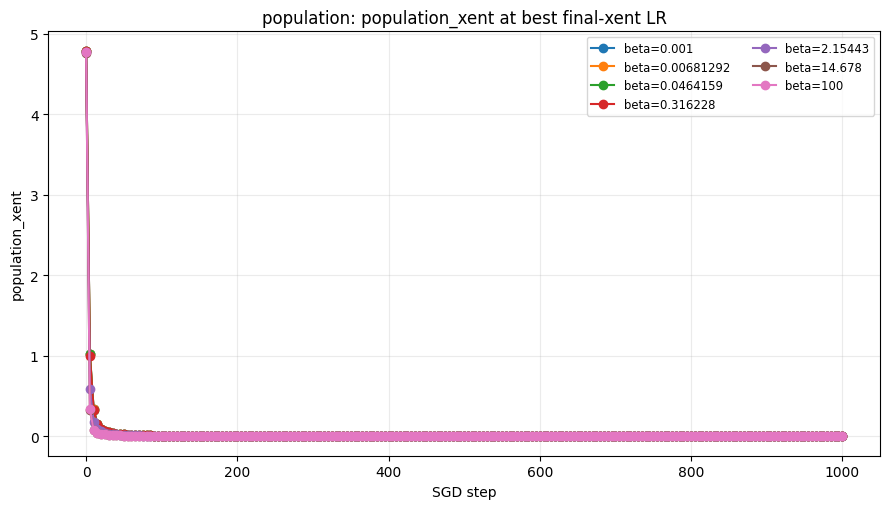

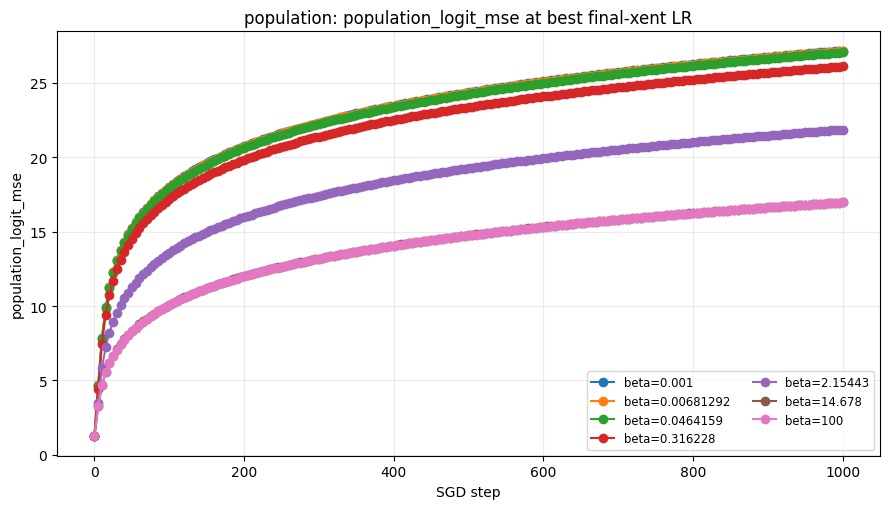

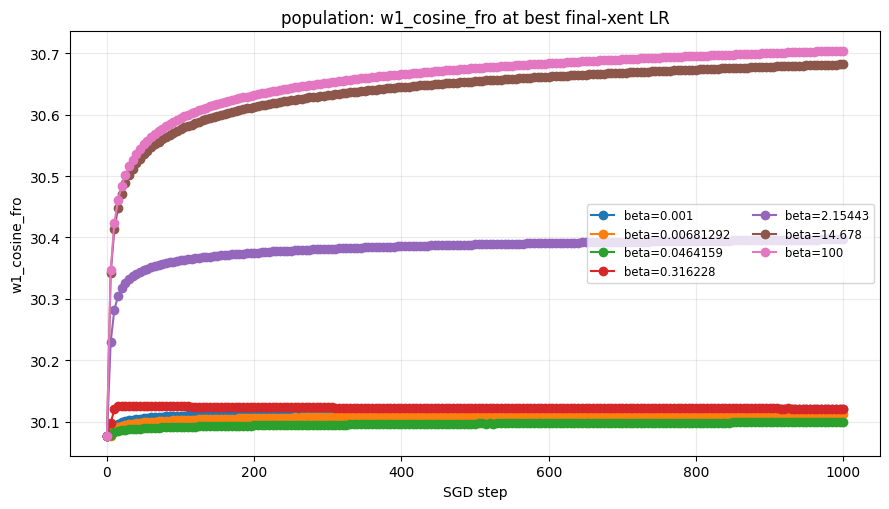

In [10]:
for mode in ['minibatch32', 'population']:
    ts = best_lr_timeseries(df, best, mode)
    for metric in time_metrics:
        fig = plot_metric_over_time(ts, metric, mode)
        plt.show()